# Exploratory Data Analysis
## image structure

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import re
from PIL import Image
import numpy as np

### Data loading

In [2]:
data_path = Path.cwd().parent.joinpath('data/vial')
if not data_path.exists():
    raise FileExistsError("could not find the vial folder... Please check")

all_files = []
count_images = 0
#capture le dossier de split, eventuellement la catégorie si existante (bad, good etc.) le filename (ie l'id de l'image), le defect existant et l'extension de l'image
regex = r'/vial/(?P<split>[^/]+)(?:/(?P<category>([^/]+)))?/(?P<filename>[\d]+)\_(?P<defect>[^.]+)\.(?P<extension>[^$]+)'
regex_mask = r'/vial/(?P<split>[^/]+)(?:/(?P<type>([^/]+)))?/(?P<category>[^/]+)/(?P<filename>[\d]+)\_(?P<defect>[^.]+)_mask\.(?P<extension>[^$]+)'
for sub in data_path.iterdir():
    for imgs_path in sub.rglob("*.png"):
        count_images+=1
        match = re.search(regex, str(imgs_path))
        match_mask = re.search(regex_mask, str(imgs_path))
        if (imgs_path) is not None:
            img = Image.open(imgs_path)
        else:
            raise FileExistsError()
        if match is not None:
            all_files.append({
                'data_type' : 'image',
                'split' : match.group('split'),
                'category' : match.group('category'),
                'filename' : match.group('filename'),
                'defect' : match.group('defect'),
                'extension' : match.group('extension'),
                'path' : imgs_path,
                'width' : img.width,
                'height' : img.height,
                'mode' : img.mode
            })
        elif match_mask is not None:
            all_files.append({
                'data_type' : 'mask',
                'split' : match_mask.group('split'),
                'type' : match_mask.group('type'),
                'category' : match_mask.group('category'),
                'filename' : match_mask.group('filename'),
                'defect' : match_mask.group('defect'),
                'extension' : match_mask.group('extension'),
                'path' : imgs_path,
                'width' : img.width,
                'height' : img.height,
                'mode' : img.mode
            })
        else:
            print('imgs')
df = pd.DataFrame(all_files)

In [3]:
df["data_type"].value_counts(dropna=False)

data_type
image    1024
mask      105
Name: count, dtype: int64

In [4]:
df["split"].value_counts(dropna=False)

split
train                 291
test_private_mixed    276
test_private          276
test_public           245
validation             41
Name: count, dtype: int64

In [5]:
df["category"].value_counts(dropna=False)


category
NaN     552
good    367
bad     210
Name: count, dtype: int64

In [6]:
df[df["category"].isna()]["split"].value_counts(dropna=False)

split
test_private_mixed    276
test_private          276
Name: count, dtype: int64

First observation : here we see that test_private doesn't offer categories (reminder : good or bad).
Now let's dive a little deeper.

In [7]:
df[df['split']=="train"]['category'].unique()

<StringArray>
['good']
Length: 1, dtype: str

Here we see that the training data are only "good".

In [8]:
df[df['split']=="validation"]['category'].unique()

<StringArray>
['good']
Length: 1, dtype: str

and validation is good only as well. Let's look at test data!

In [9]:
df[df['split']=='test_public']['data_type'].value_counts()

data_type
image    140
mask     105
Name: count, dtype: int64

We have, in the test_public dataset 140 images and 105 masks. Let's look into data categories now.

In [10]:
df[df['split']=='test_public'].groupby(['category','data_type'], dropna=False).size()

category  data_type
bad       image        105
          mask         105
good      image         35
dtype: int64

as anticipated, masks are associated with bad samples. Thus we have 105 defects, with the associated mask. Now let's look at the private tests datasets.

In [11]:
df[df['split'].isin(['test_private','test_private_mixed'])]['category'].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [12]:
df[df['split'].isin(['test_private','test_private_mixed'])]['data_type'].unique()

<StringArray>
['image']
Length: 1, dtype: str

test_private and test_private_mixed don't have categories, or masks. They only are images.

To summarize, at this step:
- Train and validation data are only good data
- public test data are good and bad data. Bad data handily come with a mask!
- private tests are not labeled, only images.

However, from the name of the sets, I can infer that test_private only has one type of data whereas test_private_mixed has a bit of both : good and bad.

Now let's look at the masks, and how they fit with the bad samples.

In [13]:
df[df['category']=='bad']['filename'].value_counts()

filename
006    14
000    14
011    14
014    14
004    14
001    14
010    14
005    14
009    14
007    14
013    14
012    14
008    14
002    14
003    14
Name: count, dtype: int64

In [14]:
public_bad_images_mask = (df['category'] =='bad') & (df['data_type']=='image')
public_bad_images = df[public_bad_images_mask]
public_bad_images['split'].unique(),public_bad_images['filename'].unique(),public_bad_images.axes

(<StringArray>
 ['test_public']
 Length: 1, dtype: str,
 <StringArray>
 ['006', '000', '011', '014', '004', '001', '010', '005', '009', '007', '013',
  '012', '008', '002', '003']
 Length: 15, dtype: str,
 [RangeIndex(start=843, stop=948, step=1),
  Index(['data_type', 'split', 'category', 'filename', 'defect', 'extension',
         'path', 'width', 'height', 'mode', 'type'],
        dtype='str')])

In [15]:
public_bad_masks_mask = (df['category'] =='bad') & (df['data_type']=='mask')
public_bad_mask = df[public_bad_masks_mask]
public_bad_mask['split'].unique(),public_bad_mask['filename'].unique(), public_bad_mask.axes

(<StringArray>
 ['test_public']
 Length: 1, dtype: str,
 <StringArray>
 ['014', '000', '001', '003', '008', '005', '009', '013', '010', '006', '004',
  '002', '007', '011', '012']
 Length: 15, dtype: str,
 [RangeIndex(start=983, stop=1088, step=1),
  Index(['data_type', 'split', 'category', 'filename', 'defect', 'extension',
         'path', 'width', 'height', 'mode', 'type'],
        dtype='str')])

In [16]:
img_id = set(public_bad_images['filename'])
mask_id = set(public_bad_mask['filename'])
img_id-mask_id, mask_id-img_id

(set(), set())

We can now see that there is a correspondance between masks and images, and that for each bad image, there is a mask and vice versa. Let's look at a particular example.

In [17]:
public_bad_images[public_bad_images['filename'] == '000']

,data_type,split,category,filename,defect,extension,path,width,height,mode,type
844,image,test_public,bad,000,shift_4,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,NaN
848,image,test_public,bad,000,regular,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,NaN
854,image,test_public,bad,000,underexposed,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,NaN
888,image,test_public,bad,000,shift_2,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,NaN
909,image,test_public,bad,000,shift_3,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,NaN
936,image,test_public,bad,000,overexposed,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,NaN
945,image,test_public,bad,000,shift_1,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,NaN


In [18]:
public_bad_mask[public_bad_mask['filename']=='000']

,data_type,split,category,filename,defect,extension,path,width,height,mode,type
984,mask,test_public,bad,000,underexposed,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,ground_truth
986,mask,test_public,bad,000,overexposed,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,ground_truth
987,mask,test_public,bad,000,shift_4,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,ground_truth
997,mask,test_public,bad,000,shift_3,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,ground_truth
1002,mask,test_public,bad,000,regular,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,ground_truth
1057,mask,test_public,bad,000,shift_1,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,ground_truth
1077,mask,test_public,bad,000,shift_2,png,/home/antoine/manuf-anom-detector/data/vial/te...,1400,1900,L,ground_truth


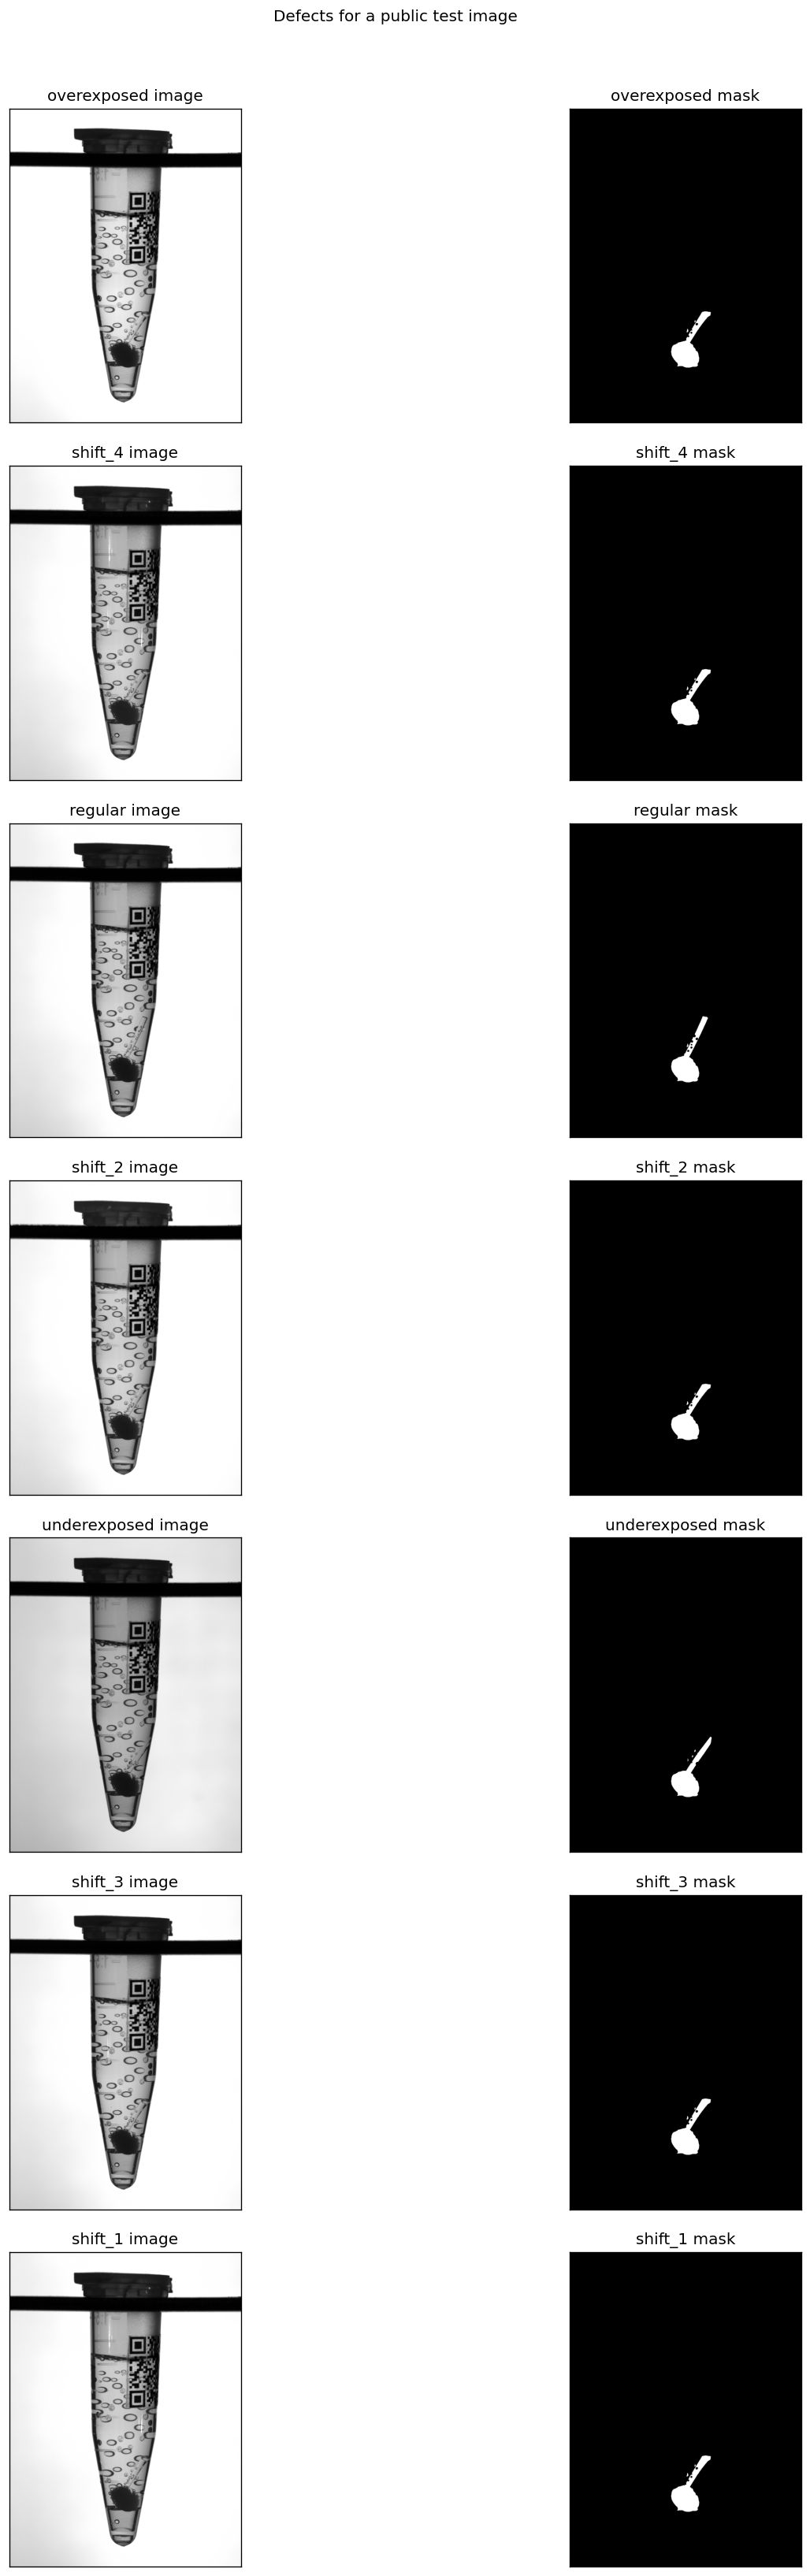

In [19]:
img_0 = public_bad_images[public_bad_images['filename'] == '000']
mask_0 = public_bad_mask[public_bad_mask['filename']=='000']

unique_defects = public_bad_images['defect'].unique()
fig,axes = plt.subplots(nrows=7, ncols=2,figsize=(12, 28), dpi=120)
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.suptitle('Defects for a public test image')


for i, defect in enumerate(public_bad_images['defect'].unique()):
    img_defect_path = img_0[img_0['defect']==defect]['path'].iloc[0]
    mask_defect_path = mask_0[mask_0['defect']==defect]['path'].iloc[0]

    img_defect = cv.imread(img_defect_path, cv.IMREAD_GRAYSCALE)
    mask_defect = cv.imread(mask_defect_path, cv.IMREAD_GRAYSCALE)

    axes[i,0].imshow(img_defect, cmap='gray')
    axes[i,0].set_title(f'{defect} image')
    axes[i,0].get_xaxis().set_visible(False)
    axes[i,0].get_yaxis().set_visible(False)
    
    axes[i,1].imshow(mask_defect, cmap='gray')
    axes[i,1].set_title(f'{defect} mask')
    axes[i,1].get_xaxis().set_visible(False)
    axes[i,1].get_yaxis().set_visible(False)
    

Now looking at these defects, we see that the bad images have various expositions, and that some images are shifted.
A next step would be to look into the specific center of each image, compare shifts center with the regular center, and see how much luminosity vary between regular, overexposed, underexposed image.
Now I will look into image dimensions.

In [20]:
#let's see if all image have the same width or height, ie can I assume a fixed size for all inputs?
df['width'].unique(), df['height'].unique()
#Thus we see that all images have the same shape, same aspect ratio.

(array([1400]), array([1900]))

In [21]:
df.groupby(['width','height']).size()

width  height
1400   1900      1129
dtype: int64

all images have the same spatial resolution, that will make our pre-processing easier. When it comes to processing, multiple image manipulation will be done, but it's good to know that data that will enter the transformation pipeline have the same dimensions.

## Masks analysis
Now let's look into more details to the bad images & associated masks.
We need to get a little bit more understanding on where the defaults are localized, and if I can get some information at this stage from the masks themselves.

In [22]:
#let's retrieve our first img & associated masks to further study it
img_defect_path = img_0[img_0['defect']==defect]['path'].iloc[0]
mask_defect_path = mask_0[mask_0['defect']==defect]['path'].iloc[0]

img_defect = cv.imread(img_defect_path, cv.IMREAD_GRAYSCALE)
mask_defect = cv.imread(mask_defect_path, cv.IMREAD_GRAYSCALE)

mask_defect.min(), mask_defect.max(), mask_defect.view(), np.unique(mask_defect)

(np.uint8(0),
 np.uint8(255),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(1900, 1400), dtype=uint8),
 array([  0, 255], dtype=uint8))

From an example in our dataset, we see our mask is either 0 or 255s. This will be helpful to look into how many pixels are errors relative to image dimension.

In [23]:
#anomaly ratio
int((mask_defect > 0).sum())/ (mask_defect.shape[0] * mask_defect.shape[1])

0.010738721804511278

In our example mask, the anomaly occupies a very small portion of the image (less than 2%). It seems that the anomaly is spatially localized. Let's confirm this !

In [25]:
#number of connected components
#let's start by thresholding & binarizing our masks, and ensuring values are either 0 or 1s, with data type uint8 (expected by cv2)
mask_defect_bin = (mask_defect > 0).astype(np.uint8)
num_labels,labels, stats, centroids = cv.connectedComponentsWithStatsWithAlgorithm(mask_defect_bin, connectivity=8, ltype=cv.CV_32S, ccltype=cv.CCL_DEFAULT)
stats[1:, cv.CC_STAT_AREA], centroids.shape, (stats[1:, cv.CC_STAT_AREA] /stats[1:, cv.CC_STAT_AREA].sum())*100

(array([28360,    65,   140], dtype=int32),
 (4, 2),
 array([99.28233853,  0.2275512 ,  0.49011027]))

Using the connected components method of opencv, we see that we have 3 main areas (excluding the background), of which one is overly represented. The two other areas are really small compared to the major one, and are dwarfed by the latter, but let's remember that the defaults is approx. 1% of the total image, and hence still a minor % of all the information.
Now that we have analysed one mask, let's pursue with multiple masks to uncover more information on this dataset.

In [ ]:
masks = df[df['data_type']=='mask']

def extract_mask_features(mask_path : str):
        mask = (cv.imread(mask_path,cv.IMREAD_GRAYSCALE) > 0).astype(np.uint8)
        num_labels,labels, stats, centroids = cv.connectedComponentsWithStatsWithAlgorithm(mask,connectivity=8, ltype=cv.CV_32S,ccltype=cv.CCL_DEFAULT)
        return {
                'num_labels' : num_labels,
                'labels' : labels,
                'stats_no_bckgrd' : stats[1:, cv.CC_STAT_AREA],
                'ratio' : (stats[1:, cv.CC_STAT_AREA]/stats[1:, cv.CC_STAT_AREA].sum()) * 100
        }